In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from tqdm import tqdm

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problems.riemannian_ambient_flow import RiemannianAmbientFlowProblem
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.parity.tanh import TanhParityTransform
from src.transforms.parity.polynomial import PolynomialParityTransform
from src.transforms.householder_linear import HouseholderLinearTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

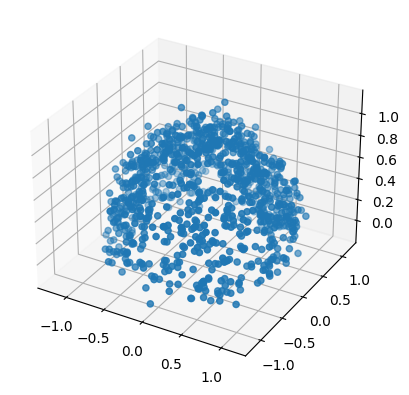

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_clean = uniform_sphere_sampling(3, num_samples)
# data_clean_mean = data_clmean
data_train_clean = data_clean
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self, pseudo_inverse_reg=None):
        super().__init__()
        self.lambd = pseudo_inverse_reg

    def forward(self, x):
        return x
    
    def pseudo_inverse(self, y):
        if self.lambd is not None:
            return 1 / (1 + self.lambd) * y
        else:
            return y

In [4]:
class ResidualBlockMLP(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        hidden_dim = hidden_dim
        self.fc1 = nn.Linear(2*dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 2*dim)
        
    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out += identity
        return out

class ResNetMLP(nn.Module):
    def __init__(self, dim, hidden_dim, n_blocks):
        super().__init__()
        self.blocks = nn.Sequential(
            *[ResidualBlockMLP(dim, hidden_dim) for _ in range(n_blocks)]
        )

    def forward(self, x):
        return self.blocks(x)

In [5]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, n_hoho, order):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(transforms.normalization.ActNorm(features=dim))
        for k in range(n_hoho):
            transforms_list.append(HouseholderLinearTransform(dim))
        transforms_list.append(TanhParityTransform(dim, order, parity=i%2))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return NFlowVectorDiffeomorphism(dim, flows.Flow(transform=flow_transforms, distribution=base_dist))

In [6]:
# Define the conditional normalizing flow model
def create_conditional_distribution_model(dim, hidden_dim, n_blocks):
    context_encoder = ResNetMLP(dim, hidden_dim, n_blocks)
    return distributions.ConditionalDiagonalNormal(shape=[dim], context_encoder=context_encoder)


In [ ]:
# Initialize the model
dim = 3

pseudo_inverse_reg = 0.1
forward = IdentityForward(pseudo_inverse_reg=pseudo_inverse_reg)

n_flows = 3
n_hoho = 3
order = 2
prior_nflow_diffeo = create_flow_model(dim, n_flows, n_hoho, order)

n_blocks = 1
hidden_dim = 8
posterior_dist = create_conditional_distribution_model(dim, hidden_dim, n_blocks)

model = RiemannianAmbientFlowProblem(forward, prior_nflow_diffeo, posterior_dist, noise_level).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.1)

In [ ]:
# Training loop
def train(model, train_loader, optimizer, n_epochs):
    for epoch in range(n_epochs):
        for y in tqdm(train_loader):
            optimizer.zero_grad()
            
            y = y.to(device)
            # Compute loss
            loss = model.reconstruction_loss(y)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [9]:
# Train the model
n_epochs = 250
train(model, train_loader, optimizer, n_epochs)

100%|██████████| 8/8 [00:00<00:00, 11.72it/s]


Epoch 1/250, Loss: 43.3049


100%|██████████| 8/8 [00:00<00:00, 12.79it/s]


Epoch 2/250, Loss: 38.3743


100%|██████████| 8/8 [00:00<00:00, 13.42it/s]


...

Epoch 248/250, Loss: 5.8647


100%|██████████| 8/8 [00:00<00:00, 14.18it/s]


Epoch 249/250, Loss: 5.8154


100%|██████████| 8/8 [00:00<00:00, 13.63it/s]

Epoch 250/250, Loss: 5.7722


In [10]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.phi_prior.nflow.sample(n_samples).cpu()
    return samples

In [11]:
@torch.no_grad()
def generate_samples_with_context(model, n_samples, y):
    context = model.get_context(y[None])
    samples = model.p_post.sample(n_samples, context=context).squeeze().cpu()
    return samples

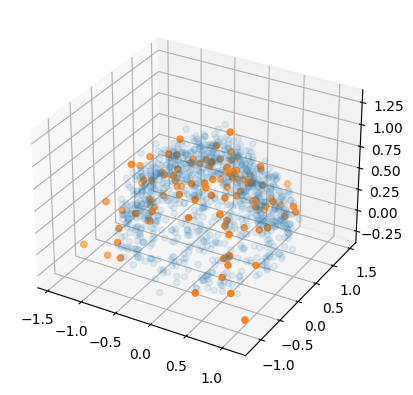

In [12]:
# Visualize generated samples
samples = generate_samples(model, 100)

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
plt.show()

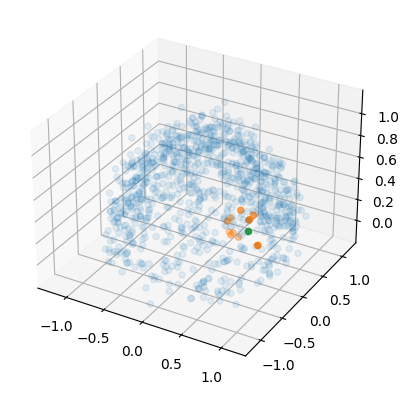

In [13]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model, 10, context.to(device))

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Evaluating Geometry ###

In [14]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi_prior)

In [15]:
# special points
# x0 = torch.tensor([0.,0.,1.]).to(device)
# x1 = torch.tensor([1.,0.,0.]).to(device)

x0 = torch.tensor([0.,1.,0.]).to(device)
x1 = torch.tensor([0.,-1.,0.]).to(device)

In [16]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

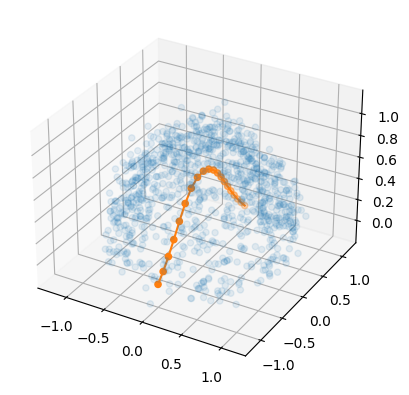

In [17]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

##### Standard RAE #####

In [18]:
# Construct RAE
epsilon = 0.1
d_epsilon = 2
rae_ = StandardPullbackVectorRiemannianAutoencoder(manifold, epsilon=epsilon, device=device)
rae = StandardPullbackVectorRiemannianAutoencoder(manifold, d_epsilon=d_epsilon, device=device)

constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.013551232405006886
constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.013551232405006886


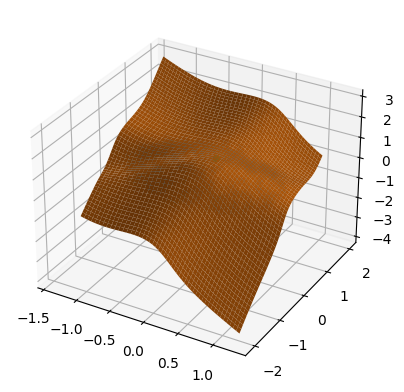

In [19]:
L = 50
x = torch.linspace(-1.5, 1.5, steps=L, device=device)
y = torch.linspace(-1.5, 1.5, steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = rae.decode(coordinates)  
    x_bar = manifold.phi.inverse(torch.zeros(1,3,device=x.device))[0].cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [20]:
rae_approximations = rae.project_on_manifold(data_train.to(device)).detach().cpu()

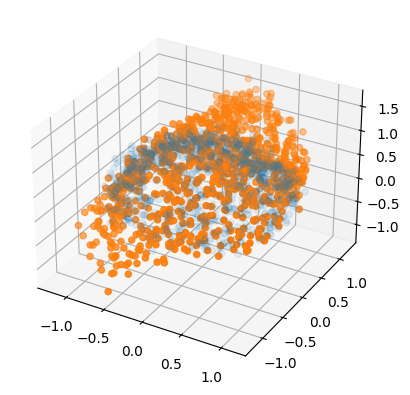

In [21]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rae_approximations[:,0], rae_approximations[:,1], rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [22]:
# compute approximation errors
print(torch.mean((data_train - rae_approximations)**2,0).sum())

tensor(0.4622)


##### Posterior RAE #####

In [23]:
# reconstruct data
rec_data_train = model.reconstruct(data_train.to(device)).detach().cpu()

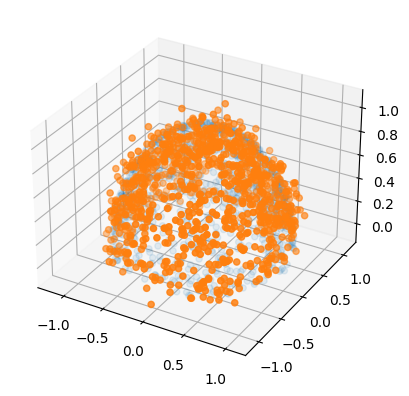

In [24]:
ax = plt.axes(projection='3d')
ax.scatter(data_train_clean[:,0], data_train_clean[:,1], data_train_clean[:,2], alpha=0.1)
ax.scatter(rec_data_train[:,0], rec_data_train[:,1], rec_data_train[:,2])
plt.show()

In [25]:
print(((data_train_clean - rec_data_train)**2).mean(0).sum().sqrt())

tensor(0.1714)


In [26]:
l2_tpca_rae = l2TangentSpacePCAPullbackVectorRiemannianAutoencoder(manifold, rec_data_train.to(device), 2)

constructed a Riemannian autoencoder with latent dimension = 2 and effectice eps = 0.07570531964302063


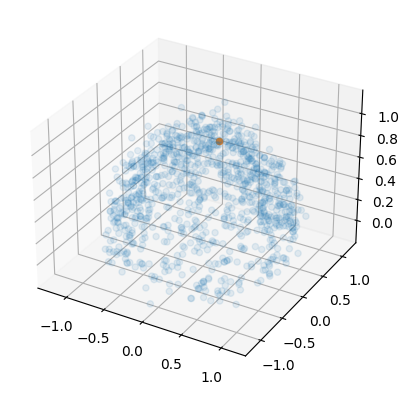

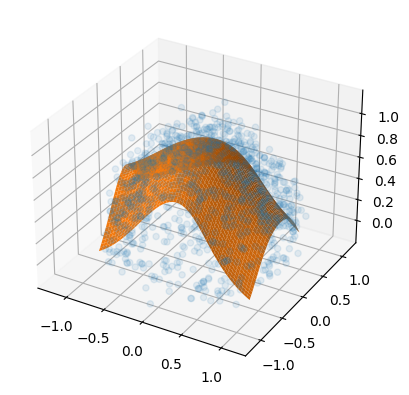

In [27]:
L = 50
x = torch.linspace(-1., 1., steps=L, device=device)
y = torch.linspace(-1., 1., steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = l2_tpca_rae.decode(coordinates)  
    x_bar = l2_tpca_rae.base_point.detach().cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [28]:
rec_l2_tpca_rae_approximations = l2_tpca_rae.project_on_manifold(rec_data_train.to(device)).detach().cpu()

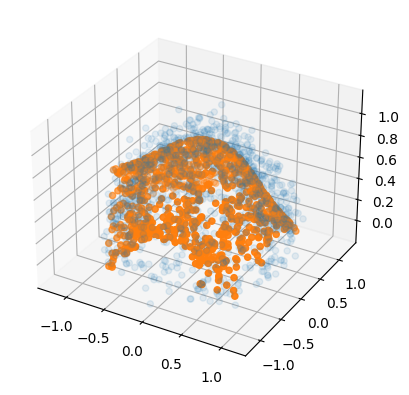

In [29]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_l2_tpca_rae_approximations[:,0], rec_l2_tpca_rae_approximations[:,1], rec_l2_tpca_rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [30]:
# compute approximation errors
print(((data_train_clean - rec_l2_tpca_rae_approximations)**2).mean(0).sum().sqrt())

tensor(0.2257)
